<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset : https://www.kaggle.com/datasets/carrie1/ecommerce-data
Customer Segment Analysis
---
Used KMeans Clustering
----
Extracted Useful Insights

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('customer_data.csv',encoding='latin1')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# PreProcessing
print(df.isna().sum())
print(df.shape)


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
(541909, 8)


In [5]:
df.dropna(inplace=True)
df.drop(columns='Description',inplace=True)
print(df.isnull().sum())
print(df.shape)

InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
(406829, 7)


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country'],
      dtype='object')

In [7]:
df['Price'] = df['Quantity'] * df['UnitPrice']


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country', 'Price'],
      dtype='object')

In [9]:
df2 = df.groupby(['InvoiceNo','InvoiceDate','CustomerID'],as_index=False).agg({'Price':'sum'})

The index of your new DataFrame df2 consists of the columns you grouped by: InvoiceNo and InvoiceDate.Because you used .groupby() on these two columns, pandas automatically turned them into a MultiIndex (a hierarchical index) and removed them from the standard columns.

In [10]:
df2.head()

,InvoiceNo,InvoiceDate,CustomerID,Price
0,536365,12/1/2010 8:26,17850.0,139.12
1,536366,12/1/2010 8:28,17850.0,22.20
2,536367,12/1/2010 8:34,13047.0,278.73
3,536368,12/1/2010 8:34,13047.0,70.05
4,536369,12/1/2010 8:35,13047.0,17.85


In [11]:
df2.shape

(22221, 4)

In [12]:
df2 = df2.loc[df2['Price'] > 0,:]
df2.shape

(18562, 4)

In [13]:
# CustomerID , Total No of invoices by that customer, total spent,
# standard deviation of spent in invoice
# days from the last invoice

In [14]:
df3 = df2.groupby(['CustomerID']).agg({'Price':'sum','InvoiceNo':'count','InvoiceDate':'max'}).reset_index()
df3


,CustomerID,Price,InvoiceNo,InvoiceDate
0,12346.0,77183.60,1,1/18/2011 10:01
1,12347.0,4310.00,7,8/2/2011 8:48
2,12348.0,1797.24,4,9/25/2011 13:13
3,12349.0,1757.55,1,11/21/2011 9:51
4,12350.0,334.40,1,2/2/2011 16:01
...,...,...,...,...
4333,18280.0,180.60,1,3/7/2011 9:52
4334,18281.0,80.82,1,6/12/2011 10:53
4335,18282.0,178.05,2,8/5/2011 13:35
4336,18283.0,2094.88,16,9/5/2011 12:35


In [15]:
df3['Recency'] = pd.Timestamp.today() - pd.to_datetime(df3['InvoiceDate'])
df3['Recency'] = df3['Recency'].dt.days
df3.head()

,CustomerID,Price,InvoiceNo,InvoiceDate,Recency
0,12346.0,77183.60,1,1/18/2011 10:01,5633
1,12347.0,4310.00,7,8/2/2011 8:48,5437
2,12348.0,1797.24,4,9/25/2011 13:13,5382
3,12349.0,1757.55,1,11/21/2011 9:51,5326
4,12350.0,334.40,1,2/2/2011 16:01,5617


In [16]:
# Final Matrix
# InvoiceDate -- drop()
# Rename --> Price to Monetary Gain, InvoiceNo --> Frequency


In [22]:
#df3.drop('InvoiceDate',inplace=True,axis=1)
df3.rename(columns={'Price':"Monetary Gain",'InvoiceNo':'Frequency'},inplace=True)
df3.columns

Index(['CustomerID', 'Monetary Gain', 'Frequency', 'Recency'], dtype='object')

In [23]:
df3.shape

(4338, 4)

In [24]:
df3.head()

,CustomerID,Monetary Gain,Frequency,Recency
0,12346.0,77183.60,1,5633
1,12347.0,4310.00,7,5437
2,12348.0,1797.24,4,5382
3,12349.0,1757.55,1,5326
4,12350.0,334.40,1,5617


In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

In [26]:
# customerID columns should not be included for clustering -- model might cluster data wrongly if this field is included.
df3.set_index('CustomerID')
X = df3

In [27]:
inertia_values = []
for k in range(2,11):
    mykmeans = KMeans(k,random_state=101)
    mykmeans.fit(X)
    inertia_values.append(mykmeans.inertia_)

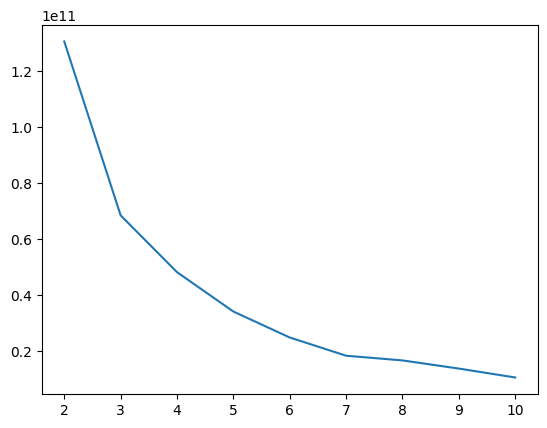

In [28]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values) # looking for angle close to 90

In [29]:
# kmeans suggesting we should create 3 clusters

In [39]:
km = KMeans(n_clusters=3,max_iter=100,random_state=101)
km.fit(X)
y_pred = km.predict(X)
print(silhouette_score(X,y_pred))

0.9286019031809888


Financial Analysis Based on Statistics

FMR Metric is used
--
F -- Frequency
--
M -- Monetory Gain
--
R -- **Recency**

In [40]:
# monetory gain : very high
# monetory gain : very high & Frequency --> high
# monetory gain : moderate & Frequency --> high
# monetory gain : high & recency --> low
# monetory gain : high & recency --> high


In [41]:
# divide data into quartiles
df3.columns

Index(['CustomerID', 'Monetary Gain', 'Frequency', 'Recency'], dtype='object')

In [42]:
# Monetory Gain
# 75% =< --> 1
# 50% - 75% --> 2
# 25% - 50% --> 3
# 25% > --> 4

def mg_calc(x):
  q1,q2,q3 = df3['Monetary Gain'].quantile([0.25,0.5,0.75])
  if x >= q3:
    return 1
  elif q2 <= x < q3:
    return 2
  elif q1 <= x < q2:
    return 3
  else:
    return 4

df3['MG'] = df3['Monetary Gain'].apply(mg_calc)
df3.head()

,CustomerID,Monetary Gain,Frequency,Recency,MG
0,12346.0,77183.60,1,5633,1
1,12347.0,4310.00,7,5437,1
2,12348.0,1797.24,4,5382,1
3,12349.0,1757.55,1,5326,1
4,12350.0,334.40,1,5617,3


In [46]:
# Monetory Gain
# 75% =< --> 1
# 50% - 75% --> 2
# 25% - 50% --> 3
# 25% > --> 4

def f_calc(x):
  q1,q2,q3 = df3['Frequency'].quantile([0.25,0.5,0.75])
  if x >= q3:
    return 1
  elif q2 <= x < q3:
    return 2
  elif q1 <= x < q2:
    return 3
  else:
    return 4

df3['F'] = df3['Frequency'].apply(f_calc)
df3.head()

,CustomerID,Monetary Gain,Frequency,Recency,MG,F,R
0,12346.0,77183.60,1,5633,1,3,4
1,12347.0,4310.00,7,5437,1,1,3
2,12348.0,1797.24,4,5382,1,2,2
3,12349.0,1757.55,1,5326,1,3,1
4,12350.0,334.40,1,5617,3,3,4


In [45]:
# Monetory Gain
# 75% =< --> 1
# 50% - 75% --> 2
# 25% - 50% --> 3
# 25% > --> 4

def r_calc(x):
  q1,q2,q3 = df3['Recency'].quantile([0.25,0.5,0.75])
  if x >= q3:
    return 4
  elif q2 <= x < q3:
    return 3
  elif q1 <= x < q2:
    return 2
  else:
    return 1

df3['R'] = df3['Recency'].apply(r_calc)
df3.head()

,CustomerID,Monetary Gain,Frequency,Recency,MG,F,R
0,12346.0,77183.60,1,5633,1,4,4
1,12347.0,4310.00,7,5437,1,3,3
2,12348.0,1797.24,4,5382,1,2,2
3,12349.0,1757.55,1,5326,1,1,1
4,12350.0,334.40,1,5617,3,4,4
